In [25]:
# Install dependencies
!pip -q install requests pandas

In [36]:
#import libraries
import requests
import pandas as pd
import numpy as np

In [37]:

BASE = "https://api.viewsforecasting.org"

def fetch_views_cm_sb(
    run,
    model="sc_cm_sb_main",
    date_start="2023-02-01",
    pagesize=15000,
    timeout=120
):
    """
    This method fetches the views forecasts for a given run and model.
    It iterates over the pages until there are non left and then return the fetched
    data as a pandas DataFrame.
    """

    url = f"{BASE}/{run}/cm/sb/{model}"
    params = {
        "date_start": date_start,
        "pagesize": pagesize,
        "page": 1
    }
    rows = []
    session = requests.Session()

    while True:
        resp = session.get(url, params=params, timeout=timeout)

        payload = resp.json()

        rows.extend(payload.get("data", []))

        next_url = payload.get("metadata", {}).get("next_page")
        if not next_url:
            break

        # After first page, follow server-provided next_page link
        url = next_url
        params = None

    return pd.DataFrame(rows)


In [38]:
# fetch predictions for march 2023 onwards
# set model run
run = "fatalities001_2023_02_t01"

# store fetched data in df
pred_views = fetch_views_cm_sb(
    run=run,
    date_start="2023-03-01"
)

#check out df
pred_views.head(), pred_views.shape


(   country_id  month_id                 name  gwcode isoab  year  month  \
 0           1       519               Guyana     110   GUY  2023      3   
 1           2       519             Suriname     115   SUR  2023      3   
 2           3       519  Trinidad and Tobago      52   TTO  2023      3   
 3           4       519            Venezuela     101   VEN  2023      3   
 4           5       519                Samoa     990   WSM  2023      3   
 
    sc_cm_sb_main  
 0         0.0157  
 1         0.0074  
 2         0.0072  
 3         0.1667  
 4         0.0199  ,
 (6876, 8))

In [39]:
# transfrom predictions form log output
pred_views["predicted_fatalities"] = np.expm1(pred_views["sc_cm_sb_main"])

In [40]:
pred_views.head(40)

,country_id,month_id,name,gwcode,isoab,year,month,sc_cm_sb_main,predicted_fatalities
0,1,519,Guyana,110,GUY,2023,3,0.0157,0.015824
1,2,519,Suriname,115,SUR,2023,3,0.0074,0.007427
2,3,519,Trinidad and Tobago,52,TTO,2023,3,0.0072,0.007226
3,4,519,Venezuela,101,VEN,2023,3,0.1667,0.181400
4,5,519,Samoa,990,WSM,2023,3,0.0199,0.020099
5,6,519,Tonga,972,TON,2023,3,0.0192,0.019386
6,7,519,Argentina,160,ARG,2023,3,0.0076,0.007629
7,8,519,Bolivia,145,BOL,2023,3,0.0092,0.009242
8,9,519,Brazil,140,BRA,2023,3,0.7045,1.022835
9,10,519,Chile,155,CHL,2023,3,0.0074,0.007427


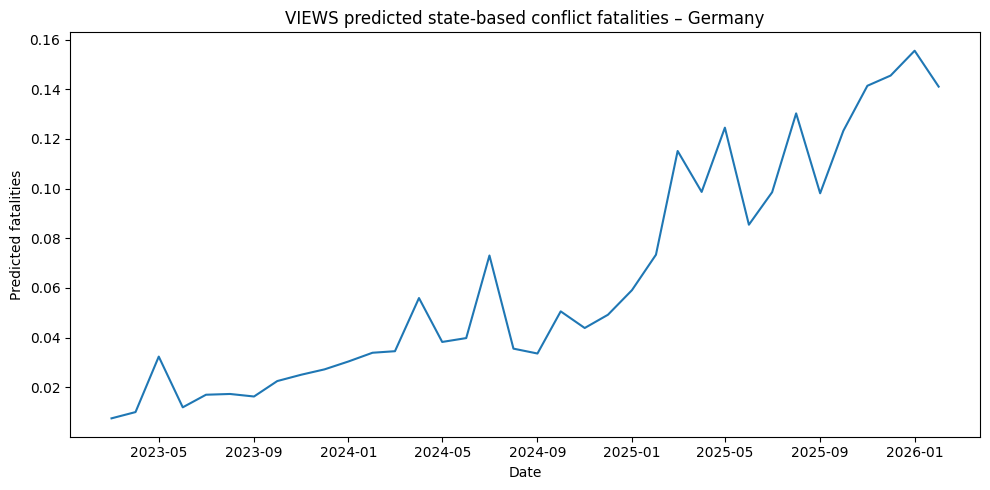

In [41]:
# check if the data is sensible
# visualize germany (should be far below 1, fluctuations should just represent noise in the low end of the log scale)
germany = pred_views[pred_views["gwcode"] == 260].copy()

germany["date"] = pd.to_datetime(
    germany["year"].astype(str) + "-" + germany["month"].astype(str) + "-01"
)

germany = germany.sort_values("date")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(germany["date"], germany["predicted_fatalities"])
plt.xlabel("Date")
plt.ylabel("Predicted fatalities")
plt.title("VIEWS predicted state-based conflict fatalities – Germany")
plt.tight_layout()
plt.show()


In [42]:
#rename columns
pred_views.rename(columns={'sc_cm_sb_main':'views_bench_ln', 'predicted_fatalities':'views_bench'}, inplace=True)

In [44]:
pred_views

,country_id,month_id,name,gwcode,isoab,year,month,views_bench_ln,views_bench
0,1,519,Guyana,110,GUY,2023,3,0.0157,0.015824
1,2,519,Suriname,115,SUR,2023,3,0.0074,0.007427
2,3,519,Trinidad and Tobago,52,TTO,2023,3,0.0072,0.007226
3,4,519,Venezuela,101,VEN,2023,3,0.1667,0.181400
4,5,519,Samoa,990,WSM,2023,3,0.0199,0.020099
...,...,...,...,...,...,...,...,...,...
6871,242,554,Tanzania,510,TZA,2026,2,0.7554,1.128463
6872,243,554,Morocco,600,MAR,2026,2,0.6147,0.849102
6873,244,554,Mauritania,435,MRT,2026,2,0.1951,0.215433
6874,245,554,Sudan,625,SDN,2026,2,1.9889,6.307491


In [46]:
#save imported file as parquet. didnt use csv because it messes with the decimals
pred_views.to_parquet("VIEWS_Benchmark_03_2023_to_03_2026.parquet")